# 循環神經網路

## 沒有記憶功能的非循環神經網路

函式 f(x) 每次被呼叫時，第一行永遠是 y = 0

這意味著：無論你上一秒輸入的是 $2$ 還是 $100$，這一次的運算都從零開始。

它不關心過去（History-independent），這就是非循環神經網路（Non-recurrent Neural Network） 的核心特性。

In [1]:
def f(x):
    y = 0  # 沒有記憶功能，每次呼叫都會重新計算
    y += x**2
    return y


print(f(2), "\t", f(3))
print(f(3), "\t", f(4))

4 	 9
9 	 16


## RNN 基本概念

RNN（Recurrent Neural Network）是一種可以處理「序列資料」的神經網路，例如：

* 文字（句子）
* 時間序列（股價）
* 語音

其核心思想是：每一步都會保留「前一刻的記憶」，每一步都依賴前一步（時間關聯）。

<img src="image/rnn.png" alt="rnn" style="width: 80%;"/>

參考圖片標示與以下不同，但概念是相同的。

## 簡化循環神經網路

這段程式碼模擬了 RNN 的簡化數學模型： $y_{t}, h_{t} = f(x_{t}, h_{t-1})$

隱藏層公式： $h_t = h_{t-1} + w_x \cdot x_t$，權重設定為 $w_x = 2$。

輸出層公式： $y_t = h_t + f(x_t)$，$f(x_t) = x^2$。

這種結構讓網路能夠處理序列型數據（如文字、股價、語音）。例如在翻譯時，網路必須記得前面的單字是「我」，後面的動詞才會選擇對應的變化。

In [2]:
class rf:
    def __init__(self):
        self.h = 0

    def forward(self, x):
        self.h += 2 * x
        return self.h + x**2

    def __call__(self, x):
        return self.forward(x)


f = rf()
print(f(2), "\t", f(3))
print(f(3), "\t", f(2))

8 	 19
25 	 24


## 定義資料

交叉熵 (Cross-Entropy) 分類：以語言模型（Language Model）為例

本範例屬於：Many-to-Many（序列 → 序列）任務

- 每個時間步都會產生一個輸出
- 每個時間步都有對應的正確答案（label）
- loss 是逐時間步計算後再平均或加總
- 本身會產生「整段序列的輸出」，不是只輸出一筆  

---

### 模型規格解析

這段程式定義了一個處理「文字序列」的小型模型結構：

* T (seq_len) = 5: 輸入句子的長度（例如：「我、喜、歡、吃、蘋」共 5 個字）
* input_dim = 4: 每個字的 embedding 維度（簡化為 4 維語意向量）
* hidden_dim = 10: RNN 內部的隱藏層大小（記憶容量）
* output_dim = 4: 字典大小（僅有 4 個可能字，簡化問題）
* batch_size = 1: 一次處理一個句子

---

### 輸入資料：Xs (Features)

* 輸入序列：假設句子為「我、愛、台、妹」

* 形狀 (Shape):

```python
(5, 1, 4)  # (時間步, 批次, embedding_dim)
```

#### 現實意義：

* 每個字被轉換成一個 `(1, 4)` 的 embedding 向量
* 這些數值代表語意特徵（而非聲音）
* 模型在每個時間步依序讀入一個字
* hidden state 會在時間步之間傳遞（RNN 核心）
* `batch_size = 1` 表示一次只處理一個句子

---

### 正確答案：Ys (Labels)

語言模型的目標是「預測下一個字」

由於 output_dim = 4，我們假設字典如下：

* 索引 0：我
* 索引 1：愛
* 索引 2：台
* 索引 3：妹

---

#### 對應關係（Shifted Sequence）

| 時間步 t | 輸入            | 正確答案（index） |
|----------|-----------------|-------------------|
| 1        | 我              | 1（愛）           |
| 2        | 愛           | 2（台）           |
| 3        | 台         | 3（妹）           |
| 4        | 妹       | 0（我）           |
| 5        | 我     | 1（愛）           |

👉 重點： $y_{t}, h_{t} = f(x_{t}, h_{t-1}) （預測下一個字）$

---

* 形狀 (Shape):

```python
(5, 1)
```

* 範例內容：

```python
[[1], [2], [3], [0], [1]]
```

#### 現實意義：

* 每個時間步都有一個 label
* Cross-Entropy 直接使用 index（不是 one-hot）
* **這代表每個時間步都會計算 loss（many-to-many）**

---

### 小結（修正版）

1. `Xs`：提供序列中每個時間步的輸入（embedding）
2. `Ys`：提供每個時間步對應的「下一字 index」
3. RNN 任務：

   * 依序處理時間步（有記憶傳遞）
   * 每個時間步都產生一個預測
4. Cross-Entropy：

   * 對每個時間步計算 loss
   * 再做平均或加總
5. 本範例類型：

> **Many-to-Many（sequence → sequence）**

6. 補充（避免誤解）：

> 若只取最後一個輸出來計算 loss，才會變成 many-to-one  
> 但本範例不是這種情況

---

In [3]:
import numpy as np

np.random.seed(1)

if True:
    T = 5
    input_dim, hidden_dim, output_dim = 4, 10, 4
    batch_size = 1
    seq_len = 5

    # 隨機生一組輸入 Xs，形狀是 (序列長度, 批次大小, 特徵維度)
    Xs = np.random.rand(seq_len, batch_size, input_dim)

    # 隨機生一組正確答案 Ys，通常是用來算 Loss 的「標籤 (Label)」
    # 用整數做分類任務 (Classification)
    Ys = np.random.randint(input_dim, size=(seq_len, batch_size))

print("輸入資料（一串文字） Xs：\n", Xs)
print("輸入資料 Xs 的形狀：", Xs.shape)
print("對應的標籤（每一個文字的下一個文字） Ys：\n", Ys)
print("對應的標籤 Ys 的形狀：", Ys.shape)

輸入資料（一串文字） Xs：
 [[[4.17022005e-01 7.20324493e-01 1.14374817e-04 3.02332573e-01]]

 [[1.46755891e-01 9.23385948e-02 1.86260211e-01 3.45560727e-01]]

 [[3.96767474e-01 5.38816734e-01 4.19194514e-01 6.85219500e-01]]

 [[2.04452250e-01 8.78117436e-01 2.73875932e-02 6.70467510e-01]]

 [[4.17304802e-01 5.58689828e-01 1.40386939e-01 1.98101489e-01]]]
輸入資料 Xs 的形狀： (5, 1, 4)
對應的標籤（每一個文字的下一個文字） Ys：
 [[1]
 [1]
 [1]
 [3]
 [3]]
對應的標籤 Ys 的形狀： (5, 1)


## 初始化模型參數

設定 RNN 網路權重，生成神經網路中所有需要「學習」的參數。權重多以隨機變數設定，並且以縮放倍率調整，偏置則是初始化為0。

* Wx (輸入層 → 隱藏層)：負責接收目前時間點的新資訊。
* Wh (隱藏層 → 隱藏層)：最關鍵的參數。它負責連結「過去的記憶」與「現在的資訊」，讓模型有連續性。
* Wf (隱藏層 → 輸出層)：將處理好的記憶轉換為最終的預測結果。
* bh & bf (偏置項)：微調神經元的觸發門檻。
* scale (縮放倍率)：將隨機產生的權重縮小（例如 0.01），防止一開始數值太大導致模型訓練不穩定。

並且也要初始化第一筆記憶（$h_0$），RNN 在處理序列（例如一段話的第一個字）時，還沒有「過去」的資訊。

* 全零初始化：建立一個全是 0 的矩陣，代表模型剛開始運作時是一片空白，沒有任何先前經驗。
* 維度：寬度是 hidden_dim（記憶容量），長度是 batch_dim（同時處理幾組資料）。

In [4]:
import numpy as np

np.random.seed(1)


# 定義 RNN 的參數初始化函式
def rnn_params_init(input_dim, hidden_dim, output_dim, scale=0.01):
    # Input → Hidden 權重
    Wx = np.random.randn(input_dim, hidden_dim) * scale

    # Hidden → Hidden 權重（時間上的遞迴連結）
    Wh = np.random.randn(hidden_dim, hidden_dim) * scale

    # Hidden 層偏置
    bh = np.zeros((1, hidden_dim))

    # Hidden → Output 權重
    Wf = np.random.randn(hidden_dim, output_dim) * scale

    # Output 層偏置
    bf = np.zeros((1, output_dim))

    # 回傳所有參數
    return [Wx, Wh, bh, Wf, bf]


# 定義 RNN 的 hidden state 初始化函式
def rnn_hidden_state_init(batch_dim, hidden_dim):
    # 初始化 hidden state（通常一開始設為 0）
    return np.zeros((batch_dim, hidden_dim))

### 初始化範例

以上一段資料定義為例，計算過程分為兩大貢獻來源，最後進行加總與活化：

外部輸入貢獻：$X (1, 4) \cdot W_x (4, 10) \to (1, 10)$將當前輸入資訊轉換為隱藏層維度。

內部記憶貢獻：$H_{old} (1, 10) \cdot W_h (10, 10) \to (1, 10)$將過去的狀態（記憶）傳遞至當前時刻。

整合與擠壓：將上述兩者與偏置 $b_h (1, 10)$ 相加。透過 tanh 函數將數值擠壓至 $(-1, 1)$ 之間，防止數值無限增長。

In [5]:
# 模型參數
params = rnn_params_init(input_dim, hidden_dim, output_dim)
# input_dim = 4, hidden_dim = 10, output_dim = 4，代表輸入特徵維度是 4，隱藏層維度是 10，輸出特徵維度是 4

print("參數的形狀：", [p.shape for p in params])
print("Wx參數的內容：", params[0])  # Wx 是第一個參數
print("Wh參數的內容：", params[1])  # Wh 是第二個參數
print("bh參數的內容：", params[2])  # bh 是第三個參數
print("Wf參數的內容：", params[3])  # Wf 是第四個參數
print("bf參數的內容：", params[4])  # bf 是第五個參數

參數的形狀： [(4, 10), (10, 10), (1, 10), (10, 4), (1, 4)]
Wx參數的內容： [[ 0.01624345 -0.00611756 -0.00528172 -0.01072969  0.00865408 -0.02301539
   0.01744812 -0.00761207  0.00319039 -0.0024937 ]
 [ 0.01462108 -0.02060141 -0.00322417 -0.00384054  0.01133769 -0.01099891
  -0.00172428 -0.00877858  0.00042214  0.00582815]
 [-0.01100619  0.01144724  0.00901591  0.00502494  0.00900856 -0.00683728
  -0.0012289  -0.00935769 -0.00267888  0.00530355]
 [-0.00691661 -0.00396754 -0.00687173 -0.00845206 -0.00671246 -0.00012665
  -0.0111731   0.00234416  0.01659802  0.00742044]]
Wh參數的內容： [[-0.00191836 -0.00887629 -0.00747158  0.01692455  0.00050808 -0.00636996
   0.00190915  0.02100255  0.00120159  0.00617203]
 [ 0.0030017  -0.0035225  -0.01142518 -0.00349343 -0.00208894  0.00586623
   0.00838983  0.00931102  0.00285587  0.00885141]
 [-0.00754398  0.01252868  0.0051293  -0.00298093  0.00488518 -0.00075572
   0.01131629  0.01519817  0.02185575 -0.01396496]
 [-0.01444114 -0.00504466  0.00160037  0.00876169  0.

In [6]:
# 隱藏狀態變數，這格通常全填 0
H_0 = rnn_hidden_state_init(batch_size, hidden_dim)

print("初始的隱藏狀態 H_0：\n", H_0)
print("初始的隱藏狀態 H_0 的形狀：", H_0.shape)

初始的隱藏狀態 H_0：
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
初始的隱藏狀態 H_0 的形狀： (1, 10)


## 向前傳播

### 基本核心公式

Hidden State（隱藏狀態），代表包含過去資訊的「記憶」，$\sigma$ 通常使用 $\tanh$ 函數作為啟動函數。

$$
h_t = \sigma(W_x x_t + W_h h_{t-1} + b)
$$

Output（輸出）

$$
y_t = \sigma(W_y h_t + c)
$$

白話文解釋：「現在的記憶 ($h_t$)」 = 「現在看到的內容 ($x_t \cdot Wx$)」 + 「過去留下的印象 ($h_{t-1} \cdot Wh$)」。

---

### 向前傳遞

初始化：

$$
h_0 = 0
$$

對每個時間步 $t$：

1. 更新記憶

$$
h_t = f(W_x x_t + W_h h_{t-1} + b)
$$

2. 產生輸出

$$
y_t = g(W_y h_t + c)
$$

---

### Loss Function（損失函式）

以下以交叉熵與 MSE 為例：

1. 單一步交叉熵（Cross Entropy）

$$
L_t = - \sum_{i} y_{t,i} \log(\hat{y}_{t,i})
$$

---

2. 單一步 MSE

$$
L_t = \frac{1}{2} \sum_{i=1}^{n} (y_{t,i} - \hat{y}_{t,i})^2
$$

---

整段序列，Loss 是「所有時間步的總和」

$$
L = \sum_{t=1}^{T} L_t
$$

In [7]:
def rnn_forward(params, Xs, H_):
    # Wx: 輸入層到隱藏層的權重
    # Wh: 前一個隱藏狀態到目前隱藏層的權重
    # bh: 隱藏層偏差
    # Wf: 隱藏層到輸出層的權重
    # bf: 輸出層偏差
    Wx, Wh, bh, Wf, bf = params

    # 設定初始隱藏狀態
    H = H_

    # Fs: 紀錄每個時間點的輸出
    # Hs: 紀錄每個時間點的隱藏狀態，方便後續反向傳播使用
    Fs = []
    Hs = {}

    # 先存入時間點 -1 的隱藏狀態，代表序列開始前的初始狀態
    Hs[-1] = np.copy(H)

    # 依序處理每一個時間點的輸入
    for t in range(len(Xs)):
        # 取出目前時間點的輸入資料
        X = Xs[t]

        # 計算目前時間點的隱藏狀態
        # 做法是把目前輸入 X 與前一個隱藏狀態 H 分別乘上對應權重後相加，
        # 再加上偏差 bh，最後通過 tanh 當作啟用函數
        H = np.tanh(np.dot(X, Wx) + np.dot(H, Wh) + bh)

        # 根據目前的隱藏狀態，計算這個時間點的輸出
        # 先做線性轉換，再加上輸出層偏差 bf
        F = np.dot(H, Wf) + bf

        # 紀錄目前時間點的輸出與隱藏狀態
        Fs.append(F)
        Hs[t] = H

    # 回傳整段序列的輸出與各時間點的隱藏狀態
    return Fs, Hs

### 試算

In [8]:
# 試算 RNN 的前向傳播
Wx, Wh, bh, Wf, bf = params
X = Xs[0]

wx = np.dot(X, Wx)
print("wx的結果", wx)
wh = np.dot(H_0, Wh)
print("wh的結果", wh)
H = np.tanh(wx + wh + bh)
print("H的結果", H)
F = np.dot(H, Wf) + bf
print("F的結果", F)

wx的結果 [[ 0.01521342 -0.01858906 -0.00660156 -0.00979571  0.00974739 -0.01755978
   0.00265607 -0.00879018  0.00665236  0.00540228]]
wh的結果 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
H的結果 [[ 0.01521225 -0.01858692 -0.00660146 -0.0097954   0.00974709 -0.01755798
   0.00265607 -0.00878996  0.00665226  0.00540223]]
F的結果 [[-1.05695258e-04 -6.91229097e-06  1.75669562e-04  6.58207263e-06]]


以下則是另一種寫法，將函式拆開利於調整函式內容

In [9]:
def rnn_forward_step(params, X, preH):
    Wx, Wh, bh, Wf, bf = params

    H = np.tanh(np.dot(X, Wx) + np.dot(preH, Wh) + bh)
    F = np.dot(H, Wf) + bf

    return F, H

In [10]:
def rnn_forward_(params, Xs, H_):
    Wx, Wh, bh, Wf, bf = params

    H = H_

    Fs = []
    Hs = {}

    Hs[-1] = np.copy(H)

    for t in range(len(Xs)):
        X = Xs[t]

        # 如果要調整RNN計算方式，可以直接在這裡改 rnn_forward_step 的內容就好，不用動到整個 rnn_forward_ 的架構
        F, H = rnn_forward_step(params, X, H)
        Fs.append(F)
        Hs[t] = H

    return Fs, Hs

向前傳播的試算

In [11]:
Fs, Hs = rnn_forward(params, Xs, H_0)
# Fs, Hs = rnn_forward_(params, Xs, H_0) # 使用rnn_forward_，兩種寫法都可以，功能一模一樣，選你喜歡的用就好

print("預測值:", Fs)
print("隱藏狀態:", Hs)
print("正確答案:", Ys)

# 印出 shape（形狀），確保預測值跟正確答案的維度是對的
print("預測值的 Shape:", Fs[0].shape, "正確答案的 Shape:", Ys[0].shape)

預測值: [array([[-1.05695258e-04, -6.91229097e-06,  1.75669562e-04,
         6.58207263e-06]]), array([[ 9.73951794e-05,  1.14443282e-07, -2.16699974e-06,
        -2.84207650e-05]]), array([[ 8.55821981e-05,  3.85134257e-05,  7.66433800e-05,
        -1.04955301e-04]]), array([[ 2.65811711e-05, -9.08105362e-05,  9.49870357e-05,
        -2.09714143e-05]]), array([[-1.16728669e-04,  8.35768891e-05,  1.65072159e-04,
        -4.53538155e-05]])]
隱藏狀態: {-1: array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]), 0: array([[ 0.01521225, -0.01858692, -0.00660146, -0.0097954 ,  0.00974709,
        -0.01755798,  0.00265607, -0.00878996,  0.00665226,  0.00540223]]), 1: array([[-0.0007347 , -0.00227325, -0.00168027, -0.00325374,  0.00146301,
        -0.00554694, -0.00170562, -0.00278912,  0.0055208 ,  0.00368356]]), 2: array([[ 0.00499218, -0.01154517, -0.00472633, -0.00985514,  0.00862004,
        -0.01787433, -0.00210018, -0.01011448,  0.01166426,  0.00944769]]), 3: array([[ 0.01124936, -0.02195288, -0.0

## 向後傳播（Backpropagation Through Time, BPTT）

### 輸出層與隱藏層的梯度

$$
\delta_t^o = \hat{y}_t - y_t
$$

$$
\delta_t^a =
\left(
W_y^\top \delta_t^o + W_h^\top \delta_{t+1}
\right) \odot \phi'(a_t)
$$

### 各梯度

$$
\frac{\partial L}{\partial W_y} = \sum_t \delta_t^o \, h_t^\top
$$

$$
\frac{\partial L}{\partial c} = \sum_t \delta_t^o
$$

$$
\frac{\partial L}{\partial W_x} = \sum_t \delta_t^a \, x_t^\top
$$

$$
\frac{\partial L}{\partial W_h} = \sum_t \delta_t^a \, h_{t-1}^\top
$$

$$
\frac{\partial L}{\partial b} = \sum_t \delta_t^a
$$

In [12]:
import math


# 梯度裁切：避免梯度爆炸
def grad_clipping(grads, alpha):
    # 算整包梯度的 L2 norm
    norm = math.sqrt(sum((grad**2).sum() for grad in grads))
    # 超過門檻就等比例縮小
    if norm > alpha:
        ratio = alpha / norm
        for i in range(len(grads)):
            grads[i] *= ratio


def rnn_backward(params, Xs, Hs, dZs, clip_value=5.0):

    # 取出參數
    Wx, Wh, bh, Wf, bf = params

    # 初始化各參數梯度
    dWx, dWh, dWf = np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(Wf)
    dbh, dbf = np.zeros_like(bh), np.zeros_like(bf)

    # 從下一個時間點傳回來的 hidden 梯度
    dh_next = np.zeros_like(Hs[0])
    h = Hs
    x = Xs

    T = len(Xs)  # time steps 數

    # 反向跑時間（BPTT）
    for t in reversed(range(T)):
        dZ = dZs[t]  # 第 t 個時間點的輸出梯度

        # Output 層參數梯度
        dWf += np.dot(h[t].T, dZ)
        dbf += np.sum(dZ, axis=0, keepdims=True)

        # 回傳到 hidden（包含當下 + 從未來傳回來的），這一層的梯度 (dh) 是「目前的輸出誤差」加上「從未來傳回來的梯度」
        dh = np.dot(dZ, Wf.T) + dh_next

        # tanh 的梯度
        dZh = (1 - h[t] * h[t]) * dh

        # Hidden 層參數梯度
        dbh += np.sum(dZh, axis=0, keepdims=True)
        dWx += np.dot(x[t].T, dZh)
        dWh += np.dot(h[t - 1].T, dZh)  # 用到前一個 hidden

        # 傳給前一個時間點
        dh_next = np.dot(dZh, Wh.T)

    # 打包梯度
    grads = [dWx, dWh, dbh, dWf, dbf]

    # 需要的話做梯度裁切（clipping），避免梯度爆炸
    if clip_value is not None:
        grad_clipping(grads, clip_value)

    return grads

以下則是另一種寫法，將函式拆開利於調整函式內容

In [13]:
def rnn_backward_step(params, dZ, X, H, H_, dh_next):
    Wx, Wh, bh, Wf, bf = params

    dWf = np.dot(H.T, dZ)
    dbf = np.sum(dZ, axis=0, keepdims=True)
    dh = np.dot(dZ, Wf.T) + dh_next
    dZh = (1 - H * H) * dh
    dbh = np.sum(dZh, axis=0, keepdims=True)
    dWx = np.dot(X.T, dZh)
    dWh = np.dot(H_.T, dZh)
    dh_next = np.dot(dZh, Wh.T)

    return dWx, dWh, dbh, dWf, dbf, dh_next

In [14]:
def rnn_backward_(params, Xs, Hs, dZs, clip_value=5.0):
    Wx, Wh, bh, Wf, bf = params
    dWx, dWh, dWf = np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(Wf)
    dbh, dbf = np.zeros_like(bh), np.zeros_like(bf)

    dh_next = np.zeros_like(Hs[0])

    T = len(Xs)

    for t in reversed(range(T)):
        dZ = dZs[t]
        H = Hs[t]
        H_ = Hs[t - 1]
        X = Xs[t]

        # 如果要調整RNN計算方式，可以直接在這裡改 rnn_backward_step 的內容就好，不用動到整個 rnn_backward_ 的架構
        dWx_, dWh_, dbh_, dWf_, dbf_, dh_next = rnn_backward_step(
            params, dZ, X, H, H_, dh_next
        )

        for grad, grad_t in zip(
            [dWx, dWh, dbh, dWf, dbf], [dWx_, dWh_, dbh_, dWf_, dbf_]
        ):
            grad += grad_t

    grads = [dWx, dWh, dbh, dWf, dbf]

    if clip_value is not None:
        grad_clipping(grads, clip_value)

    return grads

## 損失函數

### Cross-Entropy 的角色

在每個時間步，模型會輸出：

```python
logits_t.shape = (4,)  # 對應 4 個字的分數
```

> 代表：模型對「所有可能字」的預測分數（尚未經過 softmax）

---

#### 損失計算方式（關鍵）

對每個時間步：

$$
Loss_t = -\log P(y_t)
$$

整體 loss：

$$
Loss = \frac{1}{T} \sum_{t=1}^{T} -\log P(y_t)
$$

---

### 直觀理解

Cross-Entropy 的核心：懲罰模型沒有把「正確的下一個字」給高機率

---

#### 範例（預測正確）

| index | 字 | 機率  |
|-------|----|------|
| 0     | 我 | 0.1  |
| 1     | 愛 | 0.7  |
| 2     | 台 | 0.1  |
| 3     | 妹 | 0.1  |

→ loss 低

---

#### 範例（預測錯誤）

| index | 字 | 機率  |
|-------|----|------|
| 0     | 我 | 0.5  |
| 1     | 愛 | 0.1  |
| 2     | 台 | 0.3  |
| 3     | 妹 | 0.1  |

→ loss 高

---

#### 核心公式
對於單一時間點的預測，交叉熵損失函數為：
$$L = -\sum_{i=1}^{n} y_i \log(\hat{y}_i)$$
> 白話解讀：它只關心「正確標籤」對應位置的分數。分數越高，Loss 越小；分數越低，Loss 越大。

In [15]:
def softmax(Z):
    # 對輸入的 Z 做 softmax，先減掉最大值避免數值爆掉
    A = np.exp(Z - np.max(Z, axis=-1, keepdims=True))
    # 將指數結果做正規化，讓每一列加起來等於 1
    return A / np.sum(A, axis=-1, keepdims=True)


def softmax_cross_entropy(Z, y, onehot=False):
    # 樣本的總數（有幾筆資料）
    m = len(Z)

    # 先把模型輸出 Z 丟進 softmax，算出每一類的機率
    F = softmax(Z)

    if onehot:
        # 如果 y 是 one-hot 編碼
        # 直接用 cross entropy 的公式算 loss
        loss = -np.sum(y * np.log(F)) / m
    else:
        # 如果 y 是類別的 index（例如 0、1、2）
        # 把 y 攤平成一維（但這行實際上不會影響後面）
        y.flatten()

        # 取出每筆資料「正確類別」對應的機率，再取 log
        log_Fy = -np.log(F[range(m), y])

        # 把所有樣本的 loss 加起來，再取平均
        loss = np.sum(log_Fy) / m

    return loss


def cross_entropy_grad_loss(Z, y, softmax_out=False, onehot=False):
    """
    優化後的函式：共用 Softmax 運算結果，同時回傳 Loss 與 Gradient。
    """
    # 1. 決定機率分布 F (Softmax 的結果)
    if softmax_out:
        # 如果已經是 Softmax 輸出，直接共用
        F = Z
    else:
        # 如果是 Logits，算一次 Softmax 就好，後面大家都用這份 F
        F = softmax(Z)

    # 2. 計算 Loss
    # 注意：這裡我們傳入已經算好的 F，並告訴後面的函式 softmax_out=True
    # (假設你原有的 softmax_cross_entropy 有支援這個判斷，或是我們直接在這裡算)
    m = len(y)
    if onehot:
        loss = -np.sum(y * np.log(F + 1e-12)) / m
    else:
        # 這裡示範直接計算，減少函式呼叫的開銷
        loss = -np.sum(np.log(F[np.arange(m), y] + 1e-12)) / m

    # 3. 計算梯度 (Gradient)
    # 直接利用剛剛算好的 F 進行計算，效能最優
    grad = F.copy()
    if onehot:
        grad = (grad - y) / m
    else:
        grad[np.arange(m), y] -= 1
        grad /= m

    return loss, grad

In [16]:
# 通用數值梯度函式
def numerical_gradient(f, params, eps=1e-6):
    numerical_grads = []  # 用來存每一個參數對應的梯度

    for x in params:
        # x 可能是多維陣列，這裡會針對 x 裡面的每一個元素計算數值梯度
        grad = np.zeros(x.shape)  # 建立一個跟 x 形狀一樣的陣列來存梯度

        # 使用 nditer 逐一走訪 x 裡面的每個元素
        it = np.nditer(x, flags=["multi_index"], op_flags=["readwrite"])

        while not it.finished:
            idx = it.multi_index  # 目前元素的索引位置

            old_value = x[idx]  # 先把原本的值存起來

            x[idx] = old_value + eps  # 對目前的值加上一個很小的 eps
            fx = f()  # 計算 f(x + eps) 的結果

            x[idx] = old_value - eps  # 對目前的值減去一個很小的 eps
            fx_ = f()  # 計算 f(x - eps) 的結果

            # 使用中央差分法計算數值梯度
            grad[idx] = (fx - fx_) / (2 * eps)

            x[idx] = old_value  # 記得把參數值還原，避免影響後續計算
            it.iternext()  # 移動到下一個元素

        numerical_grads.append(grad)  # 將目前參數的梯度存起來

    return numerical_grads  # 回傳所有參數的梯度

In [17]:
def rnn_loss_grad(Fs, Ys, loss_fn=cross_entropy_grad_loss, flatten=True):
    # 總 loss 初始化
    loss = 0

    # 存每個時間點的輸出梯度 dF
    dFs = {}

    # 逐時間點計算
    for t in range(len(Fs)):
        F = Fs[t]  # 第 t 個時間點的預測輸出
        Y = Ys[t]  # 第 t 個時間點的正確答案

        # 如果需要就把答案攤平，避免 loss 計算出錯
        if flatten and Y.ndim >= 2:
            Y = Y.flatten()

        # 計算該時間點的 loss 與對 F 的梯度
        loss_t, dF_t = loss_fn(F, Y)

        # 累加 loss
        loss += loss_t

        # 存下該時間點的梯度
        dFs[t] = dF_t

    # 回傳總 loss 與各時間點的梯度
    return loss, dFs

## 梯度驗證

In [18]:
# -------- 檢查梯度 (Gradient Check) 的前置作業 -------------

# 1. 先生出模型參數，這就像是把模型的「骨架」架起來
params = rnn_params_init(input_dim, hidden_dim, output_dim)

print(
    "參數的形狀：", [p.shape for p in params]
)  # 把這包參數印出來看看，確保它們的形狀跟我們預期的一樣

# 2. 挖一個 Hidden state 的初始空位，這格通常全填 0
H_0 = rnn_hidden_state_init(batch_size, hidden_dim)

# 3. 跑一次 Forward Pass，看看資料餵進去後，能不能順利吐出預測值 Fs 跟隱藏狀態 Hs
Fs, Hs = rnn_forward(params, Xs, H_0)
print("預測值:", Fs)

# 4. 指定我們要用的 Loss function
loss_function = rnn_loss_grad

# 5. 先印一下 shape（形狀），確保預測值跟正確答案的維度是對的
print("預測值的 Shape:", Fs[0].shape, "正確答案的 Shape:", Ys[0].shape)
print("正確答案:", Ys)

# 6. 算出這一次 Forward 有多少 Loss，順便拿到對輸出的梯度 dFs
loss, dFs = loss_function(Fs, Ys)

# 7. 最後把這包 dFs 往回丟，算出一整組參數的梯度 grads，準備拿去跟數值梯度比對
grads = rnn_backward(params, Xs, Hs, dFs)

print(
    "參數梯度的形狀：", [g.shape for g in grads]
)  # 把算出來的梯度印出來看看，確保它們的形狀跟我們預期的一樣

參數的形狀： [(4, 10), (10, 10), (1, 10), (10, 4), (1, 4)]
預測值: [array([[-1.35051259e-04,  7.74052113e-05,  1.96944512e-04,
        -2.55243064e-05]]), array([[5.15610491e-05, 1.95131285e-04, 1.82629602e-04, 6.27027027e-05]]), array([[4.86100249e-05, 3.30273478e-04, 4.54082459e-04, 8.88867291e-05]]), array([[-1.17041446e-04,  2.17968631e-04,  2.21765228e-04,
        -3.14339268e-05]]), array([[-8.63039998e-05,  6.19468776e-05,  2.27242936e-04,
        -1.66347668e-05]])]
預測值的 Shape: (1, 4) 正確答案的 Shape: (1,)
正確答案: [[1]
 [1]
 [1]
 [3]
 [3]]
參數梯度的形狀： [(4, 10), (10, 10), (1, 10), (10, 4), (1, 4)]


In [19]:
# Ys[0]
print("正確答案 Ys[0]：", Ys[0])  # 印出第一個時間點的正確答案，看看它是什麼
print("預測值 Fs[0]：\n", Fs[0])  #
print("選取的預測值：", Fs[0][np.arange(len(Ys[0])), Ys[0]])

正確答案 Ys[0]： [1]
預測值 Fs[0]：
 [[-1.35051259e-04  7.74052113e-05  1.96944512e-04 -2.55243064e-05]]
選取的預測值： [7.74052113e-05]


In [20]:
def rnn_loss():
    # ===== 建立 RNN 計算 Loss 的流程 =====

    # 初始隱藏狀態 H_0，通常會設成全 0
    # shape: (batch_size=1, hidden_dim)
    H_0 = np.zeros((1, hidden_dim))

    # 複製一份，避免直接改到原始變數
    H = np.copy(H_0)

    # ===== Forward Pass =====
    # 丟進目前的參數 params、輸入 Xs、初始隱藏狀態 H
    # 取得：
    # Fs -> 每個時間步的輸出
    # Hs -> 每個時間步的 hidden state
    Fs, Hs = rnn_forward(params, Xs, H)

    # 指定 Loss 計算函式（同時也會回傳對輸出的梯度）
    loss_function = rnn_loss_grad

    # 計算 Loss
    # dFs 這邊只是順便回傳，我們在做數值梯度時其實只需要 loss
    loss, dFs = loss_function(Fs, Ys)

    return loss


# ===== 數值梯度檢查 (Gradient Checking) =====
# 用非常小的 epsilon (1e-6) 去微調每個參數
# 用 (f(x+e) - f(x-e)) / 2e 來暴力算斜率
# 這通常拿來當「標準答案」，對照我們手寫的 backward
numerical_grads = numerical_gradient(rnn_loss, params, 1e-6)

# ===== 相對誤差計算公式 =====
# 用 relative error 避免數值太小被放大誤差
# max(|x - y| / (|x| + |y|))，分母加 1e-8 避免除以 0
# 用 lambda 寫成一行小工具 function，簡潔好讀
diff_error = lambda x, y: np.max(
    np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y)))
)

# 印出目前的 Loss（確認 forward 沒炸掉）
print("目前的 Loss 值:", loss)

print("各個參數 [dWx, dWh, dbh, dWf, dbf] 的梯度誤差：")

# ===== 梯度逐一比對 =====
# 把手刻 backward 算出來的 grads
# 跟數值微分算出來的 numerical_grads 一個一個比
for i in range(len(grads)):
    # 如果誤差 > 1e-5
    # 通常代表 backward 某段 chain rule 寫錯
    print(f"參數 {i} 的誤差: {diff_error(grads[i], numerical_grads[i])}")


# ===== 肉眼 sanity check =====
# 隨便印幾個數值看一下
# 正負號、數量級有沒有大致對齊
print("手寫梯度前兩項:", grads[1][:2])
print("數值梯度前兩項:", numerical_grads[1][:2])

目前的 Loss 值: 6.931418396518073
各個參數 [dWx, dWh, dbh, dWf, dbf] 的梯度誤差：
參數 0 的誤差: 1.4149691121084789e-06
參數 1 的誤差: 0.0014165099911625603
參數 2 的誤差: 8.112949304461534e-08
參數 3 的誤差: 7.099863583450203e-07
參數 4 的誤差: 1.6119614447875399e-10
手寫梯度前兩項: [[ 9.69926985e-06 -1.55330586e-05 -1.07743542e-05  1.37282278e-05
   3.19399942e-08  3.45373605e-06  2.60846536e-06 -2.35625401e-05
   1.40774898e-05  1.12528237e-05]
 [-4.68443041e-05  6.41516520e-05  5.41150100e-05 -4.47643015e-05
   8.68035461e-06  4.19001844e-05 -1.41126498e-06  6.08104661e-06
  -3.03794177e-06 -2.59165324e-05]]
數值梯度前兩項: [[ 9.69935243e-06 -1.55329083e-05 -1.07736042e-05  1.37276857e-05
   3.19744231e-08  3.45368179e-06  2.60858002e-06 -2.35620412e-05
   1.40776280e-05  1.12527765e-05]
 [-4.68447503e-05  6.41513509e-05  5.41149348e-05 -4.47641924e-05
   8.68061178e-06  4.18998169e-05 -1.41131551e-06  6.08135764e-06
  -3.03801428e-06 -2.59170463e-05]]


## 參數優化

In [21]:
class SGD:
    # ===== 最基本的 SGD + Momentum 實作 =====
    # 用來更新 model 參數的 optimizer

    def __init__(self, model_params, learning_rate=0.01, momentum=0.9):
        # model_params: 外部傳進來的參數列表（例如 [W1, b1, W2, b2, ...]）
        # learning_rate: 學習率，控制每次更新幅度
        # momentum: 動量係數，讓更新方向比較平滑，不會亂跳

        self.params = model_params
        self.lr = learning_rate
        self.momentum = momentum

        # vs: 用來存每個參數對應的「速度向量」
        # 跟 params 形狀一樣，初始化為 0
        self.vs = []
        for p in self.params:
            v = np.zeros_like(p)  # 建一個跟參數同 shape 的 0 矩陣
            self.vs.append(v)

    def step(self, grads):
        # ===== 做一次參數更新 =====
        # grads: 外部算好的梯度（通常是 backward 傳回來的）

        for i in range(len(self.params)):
            grad = grads[i]  # 取出對應參數的梯度

            # Momentum 更新公式：
            # v = momentum * v + lr * grad
            # 前一輪的速度會保留一部分，加上這次的梯度
            self.vs[i] = self.momentum * self.vs[i] + self.lr * grad

            # 參數更新：
            # param = param - v
            # 用累積後的速度來調整參數
            self.params[i] -= self.vs[i]

    def scale_learning_rate(self, scale):
        # ===== 動態調整學習率 =====
        # 常見於 training 過程中做 lr decay
        # 例如：每幾個 epoch 把 lr 乘上 0.1
        self.lr *= scale


class AdaGrad:
    # ===== AdaGrad Optimizer 實作 =====
    # 核心概念：
    # 每個參數都有自己的學習率（自動調整）
    # 梯度大的參數，之後更新幅度會變小
    # 常見於 sparse feature（例如 NLP）場景

    def __init__(self, model_params, learning_rate=0.01):
        # model_params: 模型所有參數
        # learning_rate: 全域基礎學習率

        self.params = model_params
        self.lr = learning_rate

        # vs: 用來累積「梯度平方和」
        # 每個參數都會有一個對應的累積器
        self.vs = []

        # delta: 避免除以 0 的小常數（數值穩定用）
        self.delta = 1e-7

        for p in self.params:
            # 初始化為 0，shape 跟參數一樣
            v = np.zeros_like(p)
            self.vs.append(v)

    def step(self, grads):
        # ===== 做一次參數更新 =====
        # grads: backward 計算好的梯度

        for i in range(len(self.params)):
            grad = grads[i]

            # 累積梯度平方
            # v = v + grad^2
            # 這會讓常常出現大梯度的維度，v 變得很大
            self.vs[i] += grad**2

            # 參數更新公式：
            # param -= lr * grad / (sqrt(v) + delta)
            # v 越大，實際有效學習率越小
            # 等於是自動幫每個維度做 scaling
            self.params[i] -= self.lr * grad / (self.delta + np.sqrt(self.vs[i]))

    def scale_learning_rate(self, scale):
        # ===== 動態調整基礎學習率 =====
        # 有時還是會搭配 lr decay 使用
        self.lr *= scale

## RNN 訓練

跑一個 epoch（或跑到指定 iterations 就停）的 RNN 訓練迴圈範例

In [22]:
def rnn_train_epoch(
    params, data_iter, optimizer, iterations, loss_function, print_n=100
):
    # params: [Wx, Wh, bh, Wf, bf] 參數
    # data_iter: data loader / iterator，每次吐一個 batch 的 (Xs, Ys, start)
    # optimizer: 例如 SGD / AdaGrad，負責更新 params
    # iterations: 最多跑幾個 step（用來限制訓練長度）
    # loss_function: 給定輸出與標籤，回傳 (loss, dZs)
    # print_n: 每隔幾步印一次 loss

    # 把參數拆開來，方便後面取 shape 或 debug
    Wx, Wh, bh, Wf, bf = params

    # 用來記錄每一步的 loss（之後可畫圖或看收斂狀況）
    losses = []

    # iter: 手動的 step counter（不是 Python 內建 iter，那個名字被你覆蓋掉了）
    iter = 0

    # hidden_size: hidden state 維度，通常從 Wh 的 shape 推
    hidden_size = Wh.shape[0]

    # ===== 逐 batch 訓練 =====
    for Xs, Ys, start in data_iter:
        # batch_size 通常看 Xs[0] 的第一維（時間步 0 的 batch）
        batch_size = Xs[0].shape[0]

        # start 代表「這是新序列的開頭」或「要重置 hidden state」
        # 常見於 truncated BPTT 或分段讀資料時，用來決定要不要清空狀態
        if start:
            H = rnn_hidden_state_init(batch_size, hidden_size)

        # Zs: 每個時間步的輸出（可能是 logits / scores）
        # Hs: 每個時間步的 hidden state（用來做 backward）
        Zs, Hs = rnn_forward(params, Xs, H)

        # dzs: loss 對 Zs 的梯度（後面丟進 backward 當起點）
        loss, dzs = loss_function(Zs, Ys)

        # Debug 區：需要看 shape 或中間值時，把 if False 改成 if True 就好
        if False:
            print("Z.shape", Zs[0].shape)
            print("Y.shape", Ys[0].shape)
            print("H", H.shape)

        # 用 BPTT 算出各參數的梯度
        dWx, dWh, dbh, dWf, dbf = rnn_backward(params, Xs, Hs, dzs)

        # 這邊取倒數第二個（len(Hs)-2）當作「最後時刻」hidden state
        H = Hs[len(Hs) - 2]

        # 把梯度包起來丟給 optimizer
        grads = [dWx, dWh, dbh, dWf, dbf]
        optimizer.step(grads)

        # 記錄 loss
        losses.append(loss)

        # 依照 print_n 的頻率印訓練狀況，方便看有沒有收斂或爆炸
        if iter % print_n == 0:
            print("iter %d, loss: %f" % (iter, loss))

        iter += 1

        # 超過指定 iterations 就提早收工（等於只跑部分 epoch）
        if iter > iterations:
            break

    # 回傳：整段訓練的 loss list + 最後的 hidden state（方便接續訓練或做 stateful RNN）
    return losses, H

In [23]:
def mse_loss_grad(f, y):
    m = len(f)
    # 計算資料筆數（樣本數）

    loss = (1.0 / m) * np.sum((f - y) ** 2)
    # 計算 MSE（均方誤差），用來衡量預測值跟實際值的差距

    grad = (2.0 / m) * (f - y)
    # 計算 MSE 對預測值 f 的梯度，常用在梯度下降

    return loss, grad
    # 回傳 loss 值以及對應的梯度

## RNN訓練範例 1. 生成時間序列資料

### 時間序列資料

這段程式用長度T「人造的週期訊號（sin + cos）」當作時間序列資料，來示範如何用自製的 RNN（搭配前面寫的 rnn_data_iter_consecutive）做訓練。

(5000,)


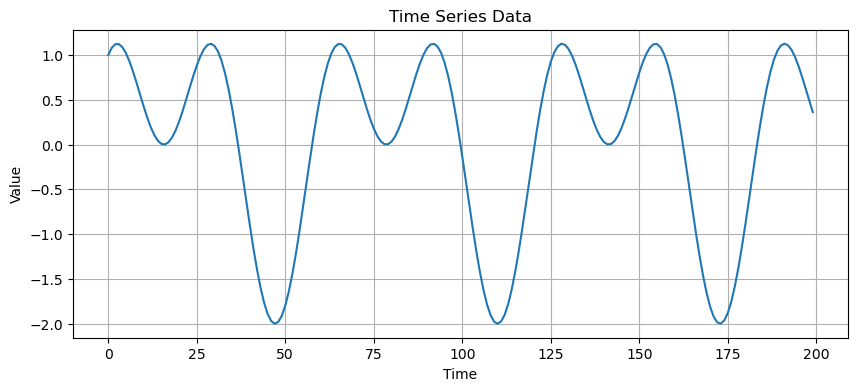

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 產生時間序列資料（sin/cos 混合波）
T = 5000  # 總點數
time = np.arange(0, T)
data = np.sin(time * 0.1) + np.cos(time * 0.2)
print(data.shape)

plt.figure(figsize=(10, 4))
# plt.plot(time, data)
plt.plot(time[:200], data[:200])
plt.title("Time Series Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)

plt.show()

### 連續取樣資料產生器（Consecutive Sampling）

In [25]:
import numpy as np


def rnn_data_iter_consecutive(data, batch_size, seq_len, start_range=10, to_3D=True):
    # 每次從不同的起點開始取樣，讓每個 epoch 的樣本略有不同
    start = np.random.randint(0, start_range)

    # 計算每個 batch 區塊可用的長度（-1 是因為 Y 要右移一格）
    block_len = (len(data) - start - 1) // batch_size

    # 取出可整除 batch_size 的連續資料作為 X / Y
    Xs = data[start : start + block_len * batch_size]
    Ys = data[start + 1 : start + block_len * batch_size + 1]

    # reshape 成 (batch_size, block_len)：每列是一條連續序列
    Xs = Xs.reshape(batch_size, -1)
    Ys = Ys.reshape(batch_size, -1)

    # 計算每條序列可切出幾段 seq_len
    reset = True
    num_batches = Xs.shape[1] // seq_len

    # 逐段切出長度為 seq_len 的樣本
    for i in range(0, num_batches * seq_len, seq_len):
        X = Xs[:, i : (i + seq_len)]
        Y = Ys[:, i : (i + seq_len)]

        # 依需求轉成 RNN 常用格式
        if to_3D:
            # 先把維度從 (batch_size, seq_len) 換成 (seq_len, batch_size)
            X = np.swapaxes(X, 0, 1)
            Y = np.swapaxes(Y, 0, 1)

            # 再補上一個 feature 維度 => (seq_len, batch_size, feature_dim)
            X = X.reshape(X.shape[0], X.shape[1], -1)
            Y = Y.reshape(Y.shape[0], Y.shape[1], -1)
        else:
            # 只做 (batch_size, seq_len) -> (seq_len, batch_size)
            X = np.swapaxes(X, 0, 1)
            Y = np.swapaxes(Y, 0, 1)

        # 第一段資料回傳 reset=True，後續為 False
        if reset:
            reset = False
            yield X, Y, True
        else:
            yield X, Y, False

簡單的測試

In [26]:
batch_size = 3
seq_len = 50
# 這裡確保起點加上 batch_size * seq_len 不會超過資料長度，避免取樣出錯
start_range = data.shape[0] - 1 - batch_size * seq_len

data_it = rnn_data_iter_consecutive(data, batch_size, seq_len, start_range, False)

# 取出第一個 batch 的資料來看看
Xs, Ys, start = next(data_it)
print("Xs shape:", Xs.shape)  # 預期 (seq_len, batch_size)
print("Ys shape:", Ys.shape)  # 預期 (seq_len, batch_size)
print("Start flag:", start)  # 預期 True（代表這是新序列的開始）
print("Xs:\n", Xs[:5])
print("Ys:\n", Ys[:5])

Xs shape: (50, 3)
Ys shape: (50, 3)
Start flag: True
Xs:
 [[0.72702503 0.02097766 0.99200548]
 [0.59603332 0.0702651  1.0676523 ]
 [0.46411262 0.14591545 1.11326285]
 [0.33833152 0.24412026 1.12424855]
 [0.22526763 0.35988841 1.09730372]]
Ys:
 [[0.59603332 0.0702651  1.0676523 ]
 [0.46411262 0.14591545 1.11326285]
 [0.33833152 0.24412026 1.12424855]
 [0.22526763 0.35988841 1.09730372]
 [0.13072972 0.48725587 1.03056598]]


### 訓練

這段程式用「人造的週期訊號（sin + cos）」當作時間序列資料，來示範如何用自製的 RNN（搭配前面寫的 rnn_data_iter_consecutive）做訓練。

附註：以下用 rnn_data_iter_consecutive 把資料切成 (X, Y, reset)：
    - X：長度 seq_length 的輸入序列
    - Y：對應右移 1 步的目標序列

In [27]:
# ===== RNN 參數設定 =====
batch_size = 3
input_dim = 1
output_dim = 1
hidden_size = 100
seq_length = 50

# ===== 訓練參數 =====
epoches = 10
learning_rate = 5e-4
iterations = 200
losses = []

# 初始化 RNN 參數與 hidden state
params = rnn_params_init(input_dim, hidden_size, output_dim)
H = rnn_hidden_state_init(batch_size, hidden_size)

# 建立資料產生器（start_range=2：每次 epoch 起點只會是 0 或 1）
data_it = rnn_data_iter_consecutive(data, batch_size, seq_length, 2)

# 取一個 batch 出來確認 shape
x, y, _ = next(data_it)
print("X:", x.shape, "Y:", y.shape, "H:", H.shape)

# 定義 loss function（這裡用 MSE 的 gradient）
loss_function = lambda F, Y: rnn_loss_grad(F, Y, mse_loss_grad, False)

# ===== 先跑一次 forward 檢查流程 =====
Zs, Hs = rnn_forward(params, x, H)
print("Z:", Zs[0].shape, "H:", Hs[0].shape)

# 計算 loss 與對輸出 Z 的梯度 dzs
loss, dzs = loss_function(Zs, y)
print(dzs[0].shape)

# 選擇 optimizer（SGD + momentum）
momentum = 0.9
optimizer = SGD(params, learning_rate, momentum)

X: (50, 3, 1) Y: (50, 3, 1) H: (3, 100)
Z: (3, 1) H: (3, 100)
(3, 1)


In [28]:
# ===== 正式訓練 =====
for epoch in range(epoches):
    # 每個 epoch 重建 iterator（start_range=100：起點更隨機）
    data_it = rnn_data_iter_consecutive(data, batch_size, seq_length, 100)

    # 跑一個 epoch（更新 iterations 次）
    epoch_losses, H = rnn_train_epoch(
        params, data_it, optimizer, iterations, loss_function, print_n=50
    )

    # 取這個 epoch 的 loss 平均值當作代表
    epoch_losses = np.array(epoch_losses).mean()
    losses.append(epoch_losses)

print("訓練完成！")
print("最後的 Loss:", losses[-1])
print("最後的 Hidden State：", H[-1])  # 印出最後一筆 hidden state 的值看看

iter 0, loss: 58.821673
iter 0, loss: 40.324205
iter 0, loss: 2.883122
iter 0, loss: 1.709496
iter 0, loss: 0.891210
iter 0, loss: 0.793938
iter 0, loss: 0.610970
iter 0, loss: 0.806396
iter 0, loss: 0.647400
iter 0, loss: 0.402380
訓練完成！
最後的 Loss: 0.025702542471160262
最後的 Hidden State： [ 0.13265365 -0.23129203 -0.09433403  0.00717819  0.06258501 -0.20717939
  0.00956101  0.18284883 -0.03736183  0.25763399 -0.09183557  0.19754922
 -0.09670835  0.15341774 -0.22019985  0.00745665  0.15537166  0.0304999
 -0.06613114 -0.04371456 -0.08951388 -0.03300534  0.07293321  0.01345805
 -0.03953219 -0.11443836 -0.25987297 -0.04725401  0.26558781  0.09873308
 -0.09325923 -0.01134751 -0.03474534  0.06462576  0.10719823 -0.2573897
  0.11690374  0.07481751 -0.19491828 -0.07700508 -0.0667226  -0.00887724
 -0.18445692 -0.15754904 -0.18239325  0.09836832 -0.26391714 -0.08082723
  0.16710375 -0.13139168  0.17496597  0.10357473  0.20382151 -0.14418137
 -0.09288625 -0.0590896   0.28110479  0.11386702  0.132130

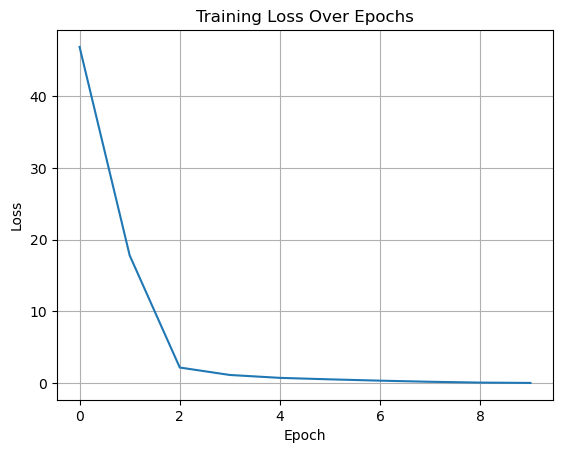

In [29]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### 預測

以下實現兩種預測方式，在 RNN 時間序列預測中，常見有兩種方式：

1. Autoregressive（自迴歸）

給模型一個起始點，讓它自己一直往前預測下去，看看能不能模擬出時間序列的演進。每一步使用「模型自己的輸出」當作下一步輸入，會有誤差累積問題，用來模擬長期預測能力。

2. Teacher Forcing（教師強制 / Ground Truth 輸入）

在訓練時用真實的資料當作下一步的輸入，而不是模型的預測值。每一步都使用「真實資料」當作輸入，不會累積誤差，用來評估模型單步預測能力。

| 項目       | Autoregressive（自迴歸） | Teacher Forcing（教師強制） |
| -------- | ------------------- | --------------------- |
| 輸入來源     | 模型前一步輸出             | 真實資料                  |
| 誤差傳遞     | 會累積                 | 不會累積                  |
| 穩定性      | 較差（長期會飄）            | 較穩定                   |
| 評估能力     | 長期預測能力              | 單步預測能力                |
| 是否貼近真實應用 | 高                   | 中                     |
| 常見用途     | 模擬未來序列              | 訓練與模型驗證               |

#### Autoregressive（自迴歸）預測

[1.12085582]
(1, 1, 1)
[[[1.12085582]]]
[1.12085582]
500


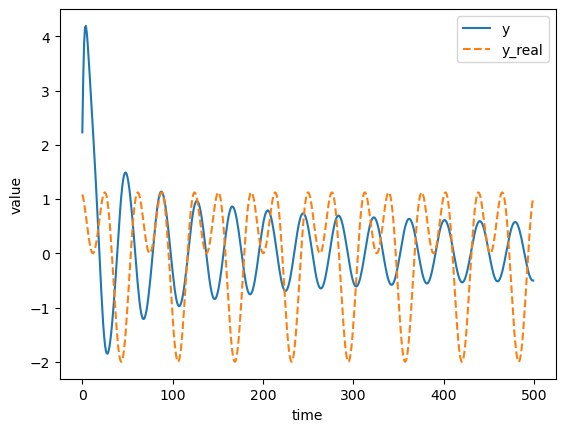

In [30]:
# 初始化 RNN 的 Hidden State（隱藏狀態），這邊先塞一個初始值給它
H = rnn_hidden_state_init(1, hidden_size)

# 設定起始點，並從資料集中切出一筆資料當作開頭
start = 3
x = data[start : start + 1].copy()
print(x)

# 調整一下 Tensor 的維度（Shape），弄成模型吃的格式
x = x.reshape(x.shape[0], 1, -1)
print(x.shape)
print(x)

# 把維度壓平一點，準備丟進去跑
x = x.reshape(1, -1)
ys = []  # 用來存預測結果的 List
print(x.flatten())

# 跑 500 次預測，模擬時間序列的演進
for i in range(500):
    # 執行 RNN 的前向傳播（Forward Step）
    # F 是當下的預測輸出，H 是更新後的隱藏狀態（會傳給下一輪）
    F, H = rnn_forward_step(params, x, H)
    x = F  # 把這一刻的輸出當作下一刻的輸入（自迴歸預測）
    ys.append(F[0, 0])

print(len(ys))

# 取出預測好的結果
ys = ys[:]

# 開始畫圖，對照預測值跟實際數值（Ground Truth）
plt.plot(ys[:500])  # 畫出預測的曲線
plt.plot(
    data[start + 1 : start + 1 + 500], linestyle="--"
)  # 畫出實際的資料，以虛線表示
plt.xlabel("time")
plt.ylabel("value")
plt.legend(["y", "y_real"])  # 標註圖例
plt.show()  # 出圖

#### Teacher Forcing（教師強制 / Ground Truth 輸入）

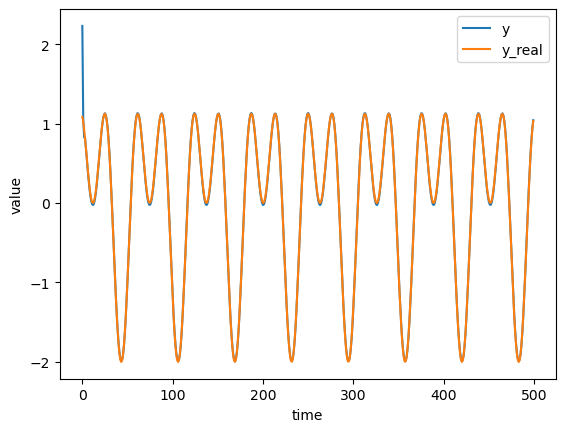

In [31]:
# 初始化 RNN 的 Hidden State（隱藏狀態），通常是在跑第一筆 sequence 前要做的事
H = rnn_hidden_state_init(1, hidden_size)

start = 3
ys = []

# 跑迴圈，長度設定為 500 次
for i in range(500):
    # 每一輪都從原始資料 (data) 裡面切出「當下這一刻」的真值 (Ground Truth)
    # 這邊是逐點 (Point-by-point) 餵進去模型
    x = data[start + i : start + i + 1].copy()

    # 把維度轉成模型吃的格式 (Shape 調整)
    x = x.reshape(1, -1)

    # 執行 Forward Step，得到預測值 F 並更新 Hidden State H
    F, H = rnn_forward_step(params, x, H)

    # 把這一步的預測結果塞進 List 存起來
    ys.append(F[0, 0])

# 雖然 ys[:] 這行沒什麼實質變動，通常是為了確保抓到的是一份副本
ys = ys[:]

# 開始用 Matplotlib 畫圖
plt.plot(ys[:500])  # 畫出模型的預測曲線
plt.plot(data[start + 1 : start + 501])  # 畫出實際的資料（比對用）
plt.xlabel("time")
plt.ylabel("value")

# 設定圖例，y 是預測值，y_real 是真實數值
plt.legend(["y", "y_real"])
plt.show()  # 顯示圖表

## RNN訓練範例 2. 股票預測

          0         1         2         3         4
0 -0.005973 -0.005916 -0.015676 -0.012310 -0.191184
1 -0.012266 -0.016172 -0.034017 -0.037249 -0.184230
2 -0.037292 -0.035058 -0.042867 -0.036047 -0.177338
3 -0.036085 -0.035675 -0.036405 -0.035448 -0.176725
4 -0.035484 -0.022362 -0.032538 -0.018456 -0.164752
(4697,)


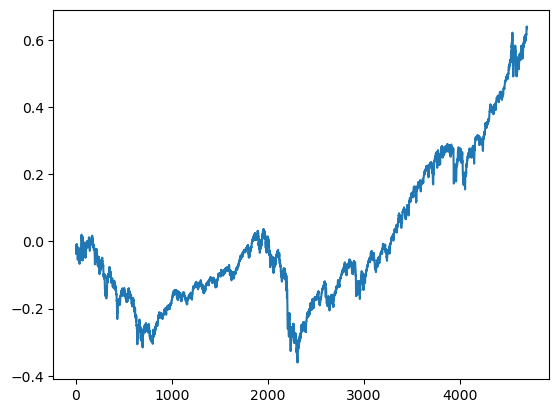

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 定義讀取股價資料的函式
# filename：CSV 檔案路徑
# normalize：是否進行正規化處理（預設為 True）
def read_stock(filename, normalize = True):    
    
    # 讀取 CSV 檔案
    data = pd.read_csv(filename)
    
    # 使用 iloc 取所有列，並選取第 1 到第 5 欄資料
    # 通常對應欄位為 Open、High、Low、Close、Volume
    data = data.iloc[:, 1:6]
    
    # 將 DataFrame 轉為 numpy array，並轉換為 float 型態
    data = data.values.astype(float)
    
    # 再轉回 pandas DataFrame，方便後續處理
    data = pd.DataFrame(data)   
    
    # 若設定需要正規化
    if normalize:
        # 對每一欄資料做正規化處理
        # 計算方式：(數值 - 平均值) / (最大值 - 最小值)
        data = data.apply(lambda x: (x - np.mean(x)) / (np.max(x) - np.min(x)))
        return data


# 讀取 sp500.csv 檔案
data = read_stock('data/sp500.csv')

# 印出前 5 筆資料確認是否成功讀取
print(data[:5])

# 取出倒數第 2 欄資料（常用來當作模型輸入特徵，例如 Close 價）
x = np.array(data.iloc[:, -2])

# 印出資料的形狀（資料筆數）
print(x.shape)
# print(x[:5])

# 繪製時間序列圖，觀察資料趨勢
plt.plot(x)

# 顯示圖表
plt.show()

定義 `stock_data_iter(data, seq_length)`：
   - 將資料依照 `seq_length` 切成多段固定長度序列。
   - 每段的 `inputs` 為連續 `seq_length` 筆資料。
   - `targets` 為對應往後偏移 1 個時間點後的倒數第 2 欄資料。
   - 回傳格式為 `(inputs, targets, is_new_sequence)`。

In [33]:
def stock_data_iter(data, seq_length):
    # 取得特徵數量（欄位數）
    feature_n = data.shape[1]

    # 計算可切出的序列段數
    # 因為 targets 需要往右偏移 1 格，所以總長度要先扣掉 1
    num = (len(data) - 1) // seq_length

    # 持續產生資料，提供訓練過程反覆取用
    while True:
        for i in range(num):
            # 每段序列的起始位置
            p = i * seq_length

            # 取出連續 seq_length 筆資料作為模型輸入
            inputs = data[p : p + seq_length]

            # targets 取下一個時間點的資料
            # 這裡只取倒數第 2 欄作為監督目標
            targets = data[p + 1 : p + seq_length + 1][:, -2]

            # 在 axis=1 增加一個維度，配合模型輸入格式
            inputs = np.expand_dims(inputs, axis=1)

            # 將 targets reshape 成 (seq_length, 1)
            targets = targets.reshape(-1, 1)

            # 第一段資料額外標記 True
            # 通常可用來表示新序列開始，或提示外部流程重置 hidden state
            if i == 0:
                yield inputs, targets, True
            else:
                yield inputs, targets, False


import numpy as np


def stock_data_shuffle_iter(data, seq_length):
    feature_n = data.shape[1]
    # 計算所有可能的起始位置 p
    # 確保 p + seq_length + 1 不會超過 data 總長度
    indices = np.arange(len(data) - seq_length)

    while True:
        # --- 關鍵修改：每個 Epoch 開始前打亂索引 ---
        np.random.shuffle(indices)

        for p in indices:
            # 取出連續 seq_length 筆資料
            inputs = data[p : p + seq_length]

            # targets 取偏移一格的資料（倒數第 2 欄）
            targets = data[p + 1 : p + seq_length + 1][:, -2]

            # 維度調整
            inputs = np.expand_dims(inputs, axis=1)
            targets = targets.reshape(-1, 1)

            # 因為順序打亂了，is_new_start 永遠為 True
            # (因為前後兩筆資料已經沒有時間上的連續關係)
            yield inputs, targets, True

### 程式碼整體說明

#### 主要功能
這段程式碼主要是在準備股價或時間序列資料，並將資料切成固定長度的序列，提供給 RNN 模型做訓練。  
模型的監督目標是「下一個時間點的倒數第 2 個欄位」，也就是用目前一段連續資料去預測下一步指定欄位的值。

#### 執行流程
1. 先將原始表格資料 `data` 轉成 `numpy array`，方便後續做切片與數值運算。
2. 印出資料形狀與前 3 筆內容，確認輸入資料格式是否正確。
3. 設定 RNN 模型所需的參數：
   - `input_dim` 依資料欄位數決定。
   - `hidden_dim` 設定 hidden state 維度。
   - `output_dim=1`，表示這是單一數值的回歸輸出。
4. 初始化 RNN 權重參數、hidden state、資料產生器與 loss function。
5. 設定訓練超參數，包括 epoch 數、學習率、每個 epoch 的 iteration 數、optimizer 等。
6. 進入訓練迴圈：
   - 每個 epoch 重新建立資料 iterator。
   - 呼叫 `rnn_train_epoch(...)` 執行訓練。
   - 收集每次訓練的 loss。
7. 最後將所有 loss 畫成曲線，觀察訓練過程的變化。

#### 重要補充
- `inputs` 透過 `np.expand_dims(inputs, axis=1)` 增加一個維度，表示模型預期的輸入格式不是單純的二維矩陣。
- `targets` 只取 `[:, -2]`，代表監督目標不是整筆下一時刻資料，而是其中某一個指定欄位。
- `if i == 0: yield ..., True` 這個設計通常是讓外部訓練流程知道目前是新序列的開始，可用於重置 RNN hidden state 或做序列邊界控制。
- 程式中使用到的 `rnn_params_init`、`rnn_hidden_state_init`、`rnn_loss_grad`、`mse_loss_grad`、`SGD`、`rnn_train_epoch`、`plt` 都是假設前面已經定義或匯入。

In [34]:
import pandas as pd
import numpy as np

# 將表格型資料轉成 numpy array
# 每一列代表一個時間點，每一欄代表一個特徵
stock_data = np.array(data)

# 印出資料形狀與前 3 筆內容，方便確認資料格式是否符合預期
print(
    "stock_data.shape", stock_data.shape
)  # 印出資料的形狀（日期 x 特徵數量：最高價、最低價、收盤價、成交量）
print("stock_data[:3]\n", stock_data[:3])

stock_data.shape (4697, 5)
stock_data[:3]
 [[-0.00597324 -0.00591629 -0.01567558 -0.01231037 -0.19118446]
 [-0.01226569 -0.01617188 -0.03401657 -0.03724877 -0.1842296 ]
 [-0.0372919  -0.03505779 -0.04286668 -0.03604657 -0.17733781]]


In [35]:
# ===== RNN 模型與訓練設定 =====
batch_size = 1
input_dim = stock_data.shape[1]  # 輸入維度 = 每個時間點的特徵數
hidden_dim = 100  # hidden state 維度
output_dim = 1  # 輸出維度，這裡是回歸問題，所以設為 1
seq_length = 100  # 每次序列展開的時間步長

# 初始化 RNN 參數
params = rnn_params_init(input_dim, hidden_dim, output_dim)

# 初始化 hidden state
H = rnn_hidden_state_init(batch_size, hidden_dim)

# 建立資料產生器，每一個 batch 都會吐出一段長度為 seq_length=100 的連續資料
data_it = stock_data_iter(stock_data, seq_length)
# data_it = stock_data_shuffle_iter(stock_data, seq_length)

# 先取一筆資料檢查輸入與目標的 shape
X, Y, _ = next(data_it)
print(X.shape, Y.shape)
print("X[0]:\n", X[0])  # 印出第一筆輸入資料，看看它的內容
print("Y[0]:\n", Y[0])  # 印出第一筆目標資料，看看它的內容

# 設定 loss function
# 這裡使用 MSE 的 gradient
# 用 lambda 包裝成訓練函式需要的介面格式
loss_function = lambda F, Y: rnn_loss_grad(F, Y, mse_loss_grad, False)

# ===== 超參數設定 =====
epoches = 2  # 訓練 epoch 數
learning_rate = 1e-4  # 學習率
iterations = 2000  # 每個 epoch 執行的訓練次數
losses = []  # 用來收集所有訓練 loss

# 使用帶 momentum 的 SGD optimizer
momentum = 0.9
optimizer = SGD(params, learning_rate, momentum)

(100, 1, 5) (100, 1)
X[0]:
 [[-0.00597324 -0.00591629 -0.01567558 -0.01231037 -0.19118446]]
Y[0]:
 [-0.03724877]


iter 0, loss: 0.105353
iter 200, loss: 0.092413
iter 400, loss: 0.561042
iter 600, loss: 0.060289
iter 800, loss: 0.446432
iter 1000, loss: 2.744471
iter 1200, loss: 0.685668
iter 1400, loss: 0.020097
iter 1600, loss: 0.007682
iter 1800, loss: 0.011944
iter 2000, loss: 0.037182
iter 0, loss: 0.015128
iter 200, loss: 0.003402
iter 400, loss: 0.003792
iter 600, loss: 0.010188
iter 800, loss: 0.003215
iter 1000, loss: 0.002941
iter 1200, loss: 0.006150
iter 1400, loss: 0.008932
iter 1600, loss: 0.002271
iter 1800, loss: 0.010422
iter 2000, loss: 0.026057


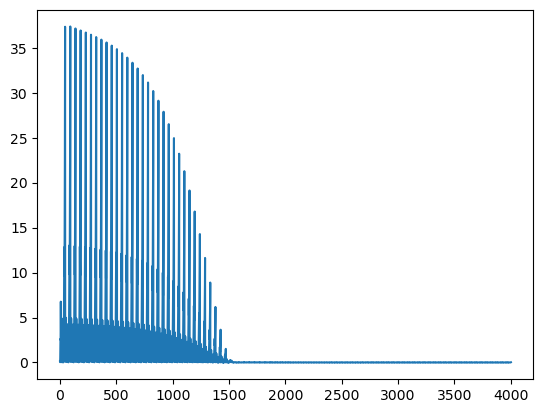

In [36]:
# ===== 開始訓練 =====
for epoch in range(epoches):
    # 每個 epoch 重新建立資料 iterator
    # 讓資料切片從頭開始
    data_it = stock_data_iter(stock_data, seq_length)

    # 執行一個 epoch 的訓練
    # print_n=200 表示每 200 次印一次訓練資訊
    epoch_losses, H = rnn_train_epoch(
        params, data_it, optimizer, iterations, loss_function, print_n=200
    )

    # 把本次 epoch 的 loss 加到總 loss 清單
    losses.extend(epoch_losses)

# 畫出 loss 曲線
# 用來觀察訓練過程是否有下降趨勢
plt.plot(losses)

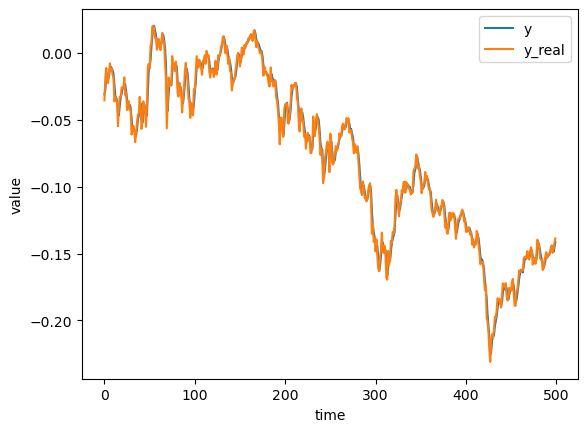

In [37]:
# 重新初始化 hidden state，這裡 batch_size 固定為 1，
# 表示後續會以單筆資料、逐時間點的方式進行推論
H = rnn_hidden_state_init(1, hidden_dim)

# 從指定的起始位置開始取資料，略過前面幾筆
start = 3
data = stock_data[start:, :]

# 用來依序存放每一步的預測結果
ys = []

# 逐筆資料進行 forward，每次只處理一個時間點
for i in range(len(data)):
    # 取出第 i 筆資料，使用 copy 避免直接影響原始資料
    x = data[i, :].copy()

    # 調整成單筆 batch 的輸入形狀：(1, input_dim)
    x = x.reshape(1, -1)

    # 執行一步 RNN forward，取得當前輸出與更新後的 hidden state
    f, H = rnn_forward_step(params, x, H)

    # 假設輸出維度為 1，取出純量預測值後存入結果列表
    ys.append(f[0, 0])

# 複製一份 ys，內容不變
ys = ys[:]

# 畫出前 500 筆模型預測結果
plt.plot(ys[:500])

# 畫出前 500 筆真實值
# 這裡使用倒數第 2 欄，需與訓練時 target 的定義一致
plt.plot(data[:500, -2])

# 設定圖表標籤與圖例
plt.xlabel("time")
plt.ylabel("value")
plt.legend(["y", "y_real"])
plt.show()

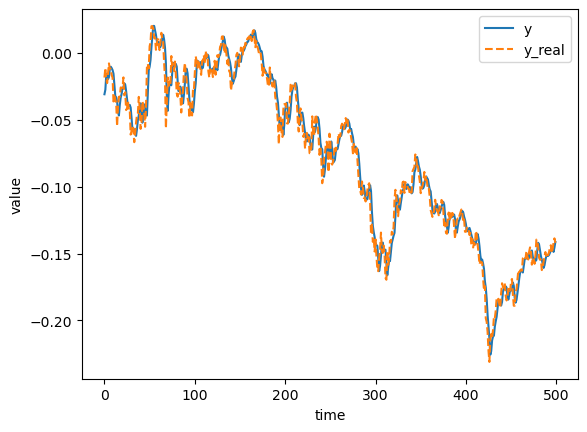

In [38]:
# 重新初始化 hidden state，batch_size = 1
H = rnn_hidden_state_init(1, hidden_dim)

# 設定起始位置
start = 3
data = stock_data[start:, :]

ys = []

# 逐步餵「真值」進模型（Teacher Forcing）
for i in range(len(data) - 1):
    # 取當下時間點的真實資料作為輸入
    x = data[i, :].copy()
    x = x.reshape(1, -1)

    # forward step
    f, H = rnn_forward_step(params, x, H)

    # 存預測值（預測的是下一個時間點）
    ys.append(f[0, 0])

# 畫預測結果
plt.plot(ys[:500])

# 畫對應的真實值（往後對齊一格）
plt.plot(data[1:501, -2], linestyle="--")

plt.xlabel("time")
plt.ylabel("value")
plt.legend(["y", "y_real"])
plt.show()